Setting up publication-quality style...
Mounted at /content/drive
✓ Setup complete

Loading results data...
✓ Data loaded

Creating Figure 1: Comprehensive Results Dashboard...


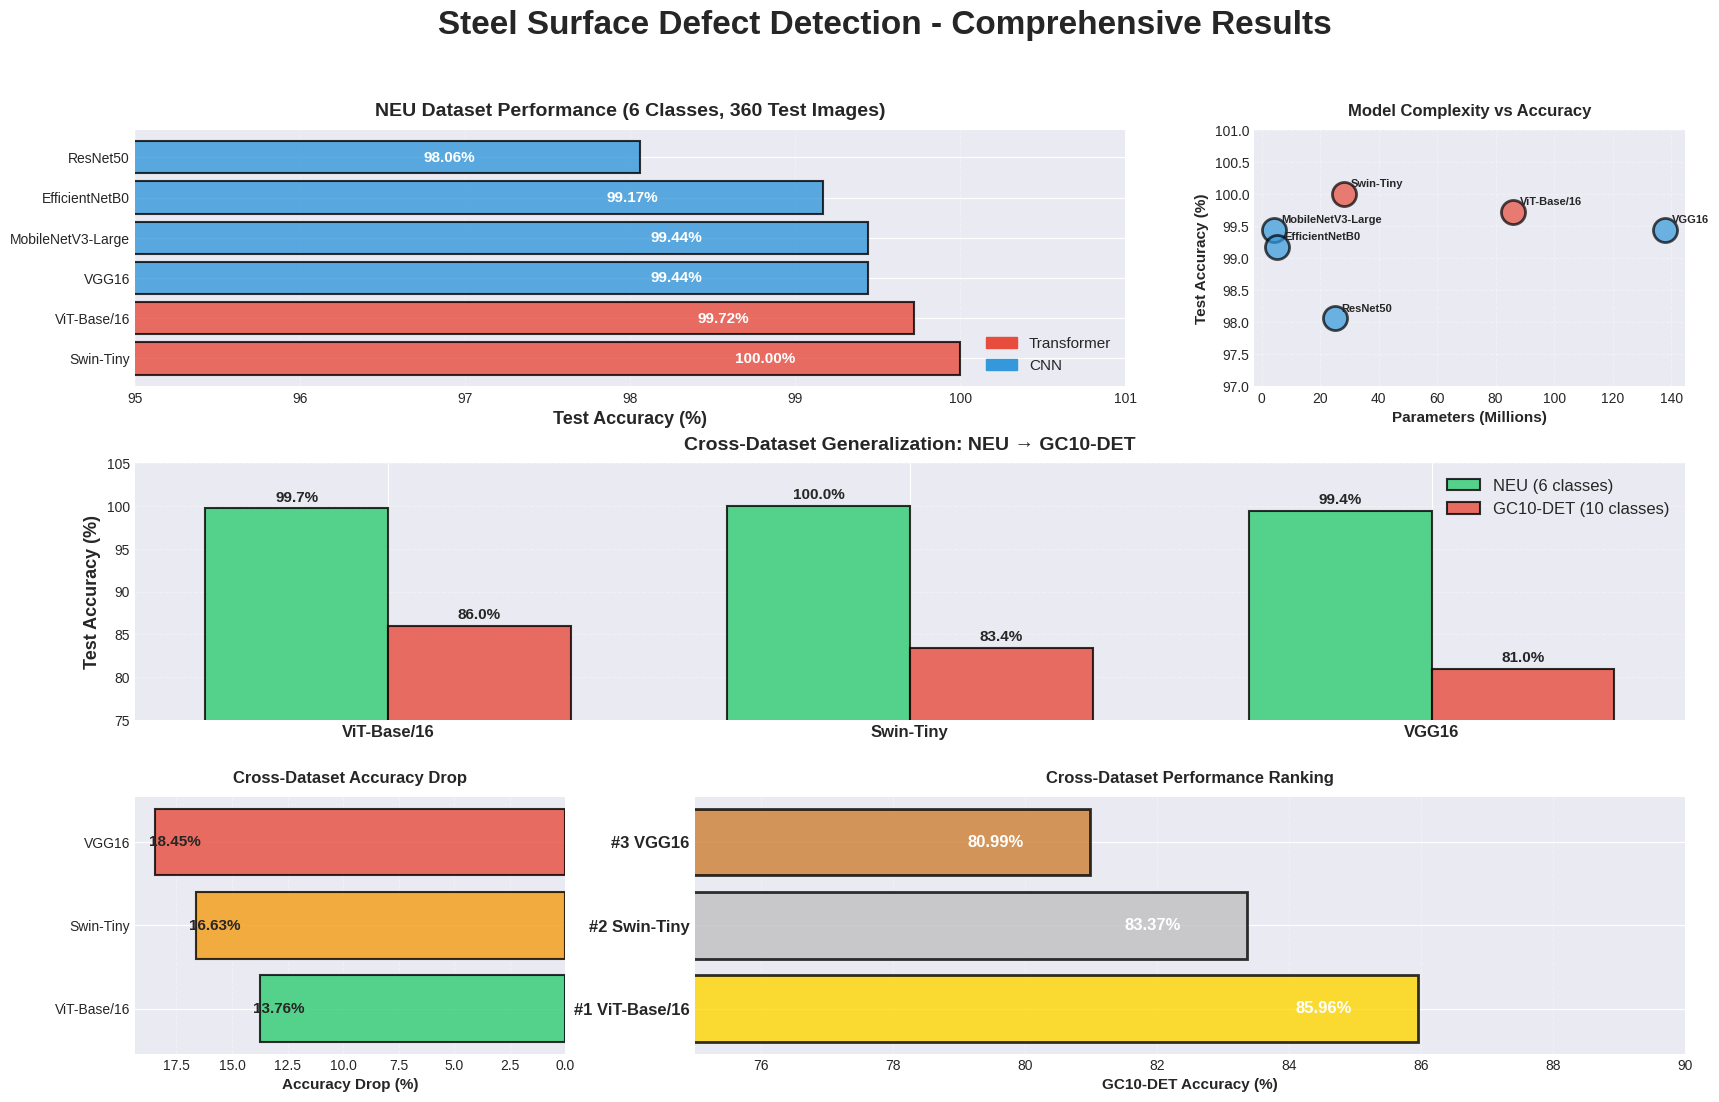

✓ Figure 1 saved: comprehensive_dashboard.png

Creating Figure 2: Architectural Comparison...


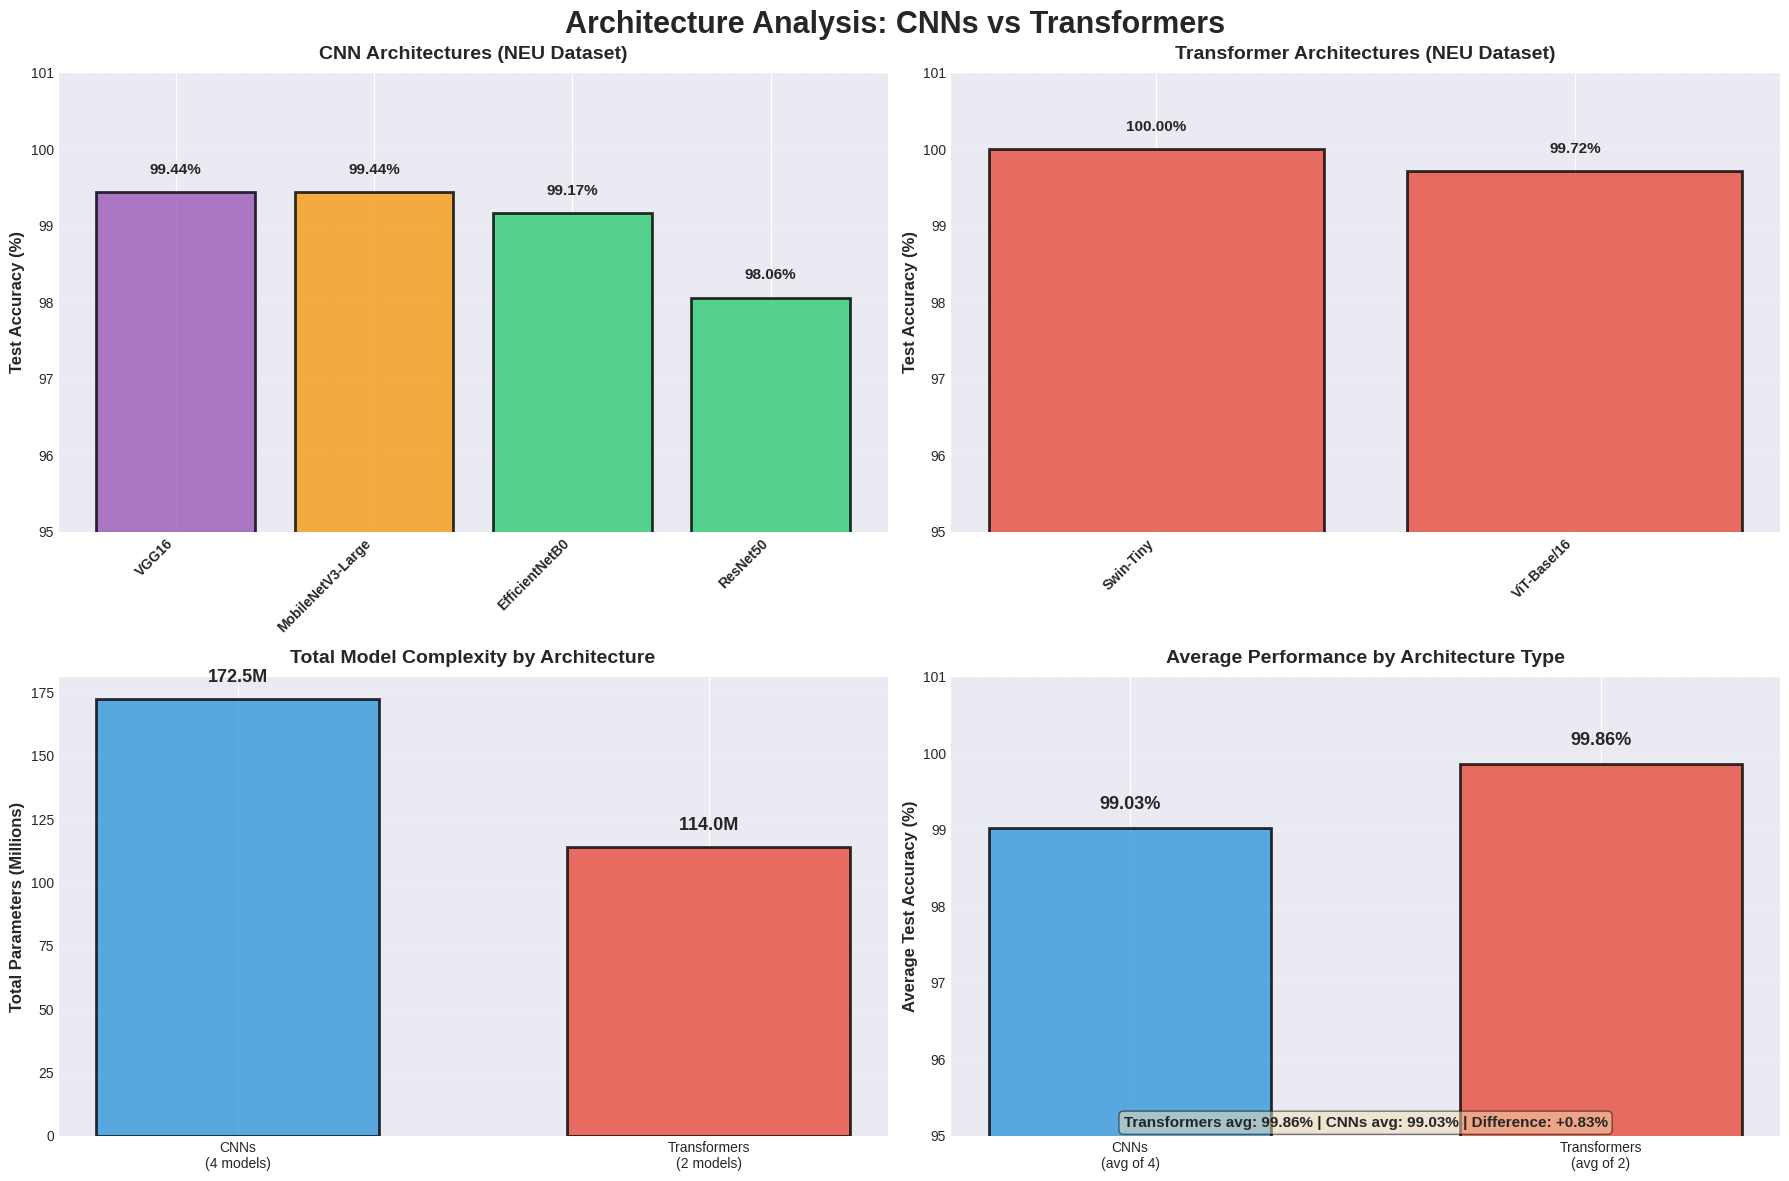

✓ Figure 2 saved: architectural_comparison.png

Creating Figure 3: Cross-Dataset Generalization Analysis...


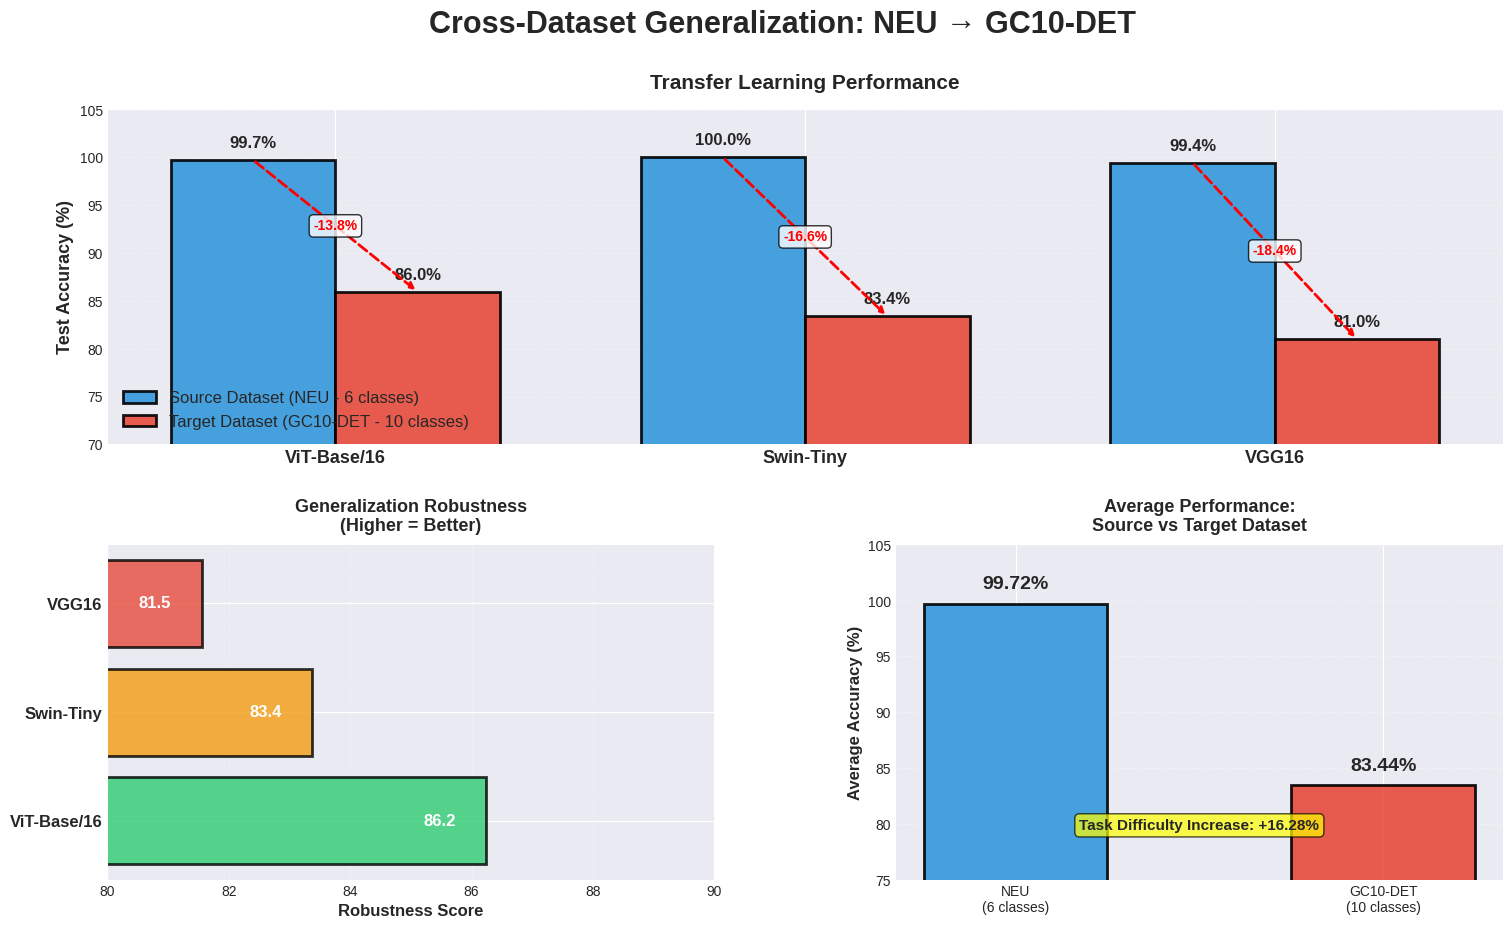

✓ Figure 3 saved: generalization_analysis.png

Creating Figure 4: Key Insights Infographic...


/tmp/ipykernel_839/3333015079.py:543: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Liberation Sans.
  plt.savefig(FIGURES_DIR / 'key_insights_infographic.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_839/3333015079.py:543: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  plt.savefig(FIGURES_DIR / 'key_insights_infographic.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_839/3333015079.py:543: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) Liberation Sans.
  plt.savefig(FIGURES_DIR / 'key_insights_infographic.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_839/3333015079.py:543: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig(FIGURES_DIR / 'key_insights_infographic.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_839/3333015079.py:543: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.savefig(FIGURES_DIR / 'key_insights_

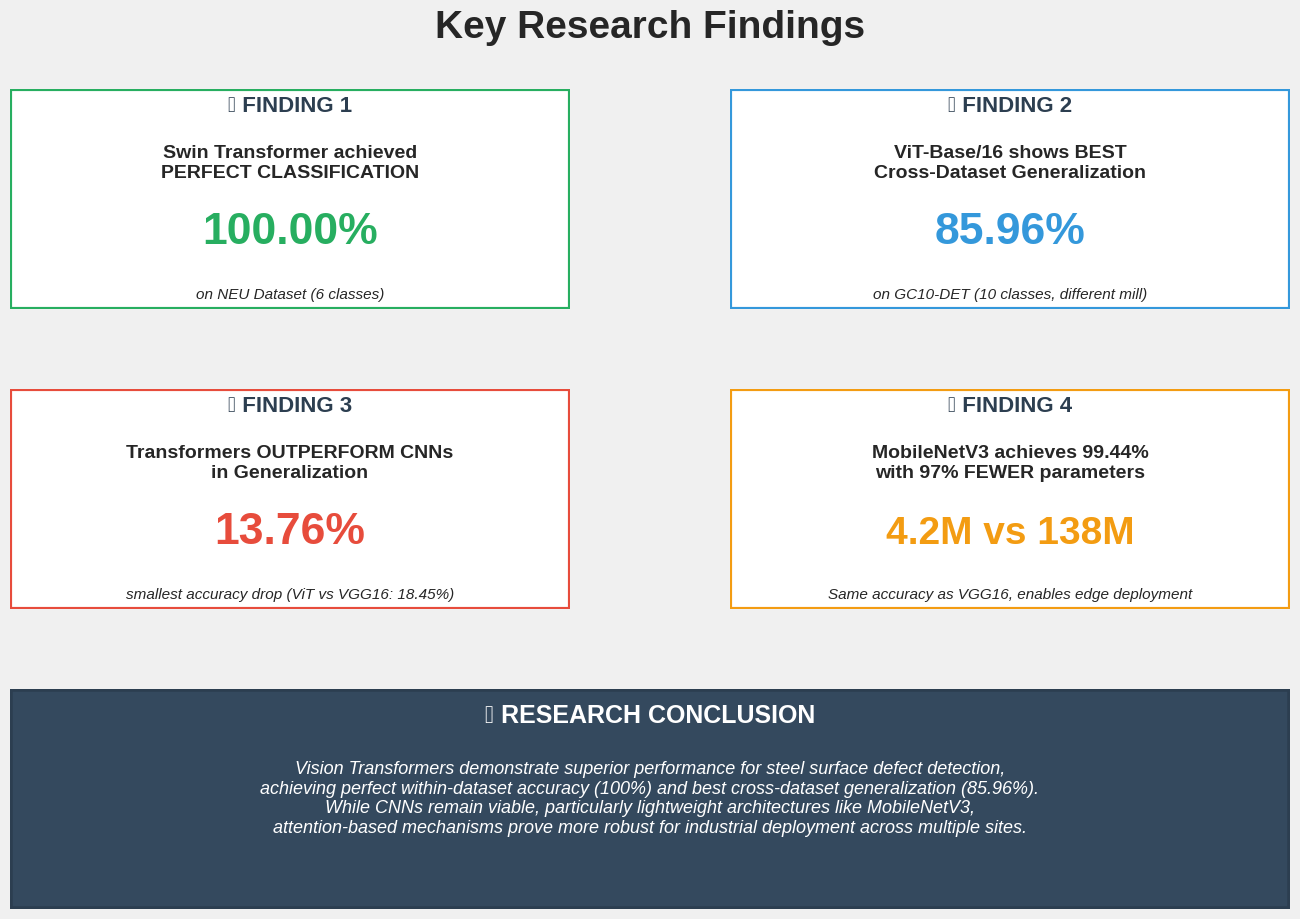

✓ Figure 4 saved: key_insights_infographic.png

✅ ALL PUBLICATION-QUALITY FIGURES CREATED!

Files saved to: /content/drive/MyDrive/FINAL PROJECT/Results/figures

Generated figures:
  1. comprehensive_dashboard.png      - Complete results overview
  2. architectural_comparison.png     - CNN vs Transformer analysis
  3. generalization_analysis.png      - Cross-dataset performance
  4. key_insights_infographic.png     - Research findings summary

These figures are:
  ✓ Publication-quality (300 DPI)
  ✓ Professional color schemes
  ✓ Clear labels and annotations
  ✓ Ready for thesis and presentation


In [1]:
"""
================================================================================
PUBLICATION-QUALITY VISUALIZATIONS
Professional figures for thesis and presentation
================================================================================
"""

# ============================================================================
# SECTION 1: SETUP & IMPORTS
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib.patheffects as path_effects

print("Setting up publication-quality style...")

# Set publication style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Custom colors
COLORS = {
    'CNN': '#3498db',
    'Transformer': '#e74c3c',
    'Efficient': '#2ecc71',
    'Heavy': '#9b59b6',
    'Light': '#f39c12'
}

# Mount drive
from google.colab import drive
drive.mount('/content/drive')

RESULTS_DIR = Path('/content/drive/MyDrive/FINAL PROJECT/Results')
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

print("✓ Setup complete")


# ============================================================================
# SECTION 2: LOAD ALL RESULTS DATA
# ============================================================================

print("\nLoading results data...")

# NEU results (from your training)
neu_results = {
    'Model': ['Swin-Tiny', 'ViT-Base/16', 'VGG16', 'MobileNetV3-Large', 'EfficientNetB0', 'ResNet50'],
    'Architecture': ['Transformer', 'Transformer', 'CNN', 'CNN', 'CNN', 'CNN'],
    'Test Accuracy (%)': [100.00, 99.72, 99.44, 99.44, 99.17, 98.06],
    'Parameters (M)': [28, 86, 138, 4.2, 5.3, 25],
    'Type': ['Transformer', 'Transformer', 'Heavy CNN', 'Light CNN', 'Efficient CNN', 'Medium CNN']
}

# GC10-DET results (from cross-dataset validation)
gc10_results = {
    'Model': ['ViT-Base/16', 'Swin-Tiny', 'VGG16'],
    'Test Accuracy (%)': [85.96, 83.37, 80.99],
    'NEU Accuracy (%)': [99.72, 100.00, 99.44],
    'Accuracy Drop (%)': [13.76, 16.63, 18.45]
}

df_neu = pd.DataFrame(neu_results)
df_gc10 = pd.DataFrame(gc10_results)

print("✓ Data loaded")


# ============================================================================
# SECTION 3: FIGURE 1 - COMPREHENSIVE RESULTS DASHBOARD
# ============================================================================

print("\nCreating Figure 1: Comprehensive Results Dashboard...")

fig = plt.figure(figsize=(20, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

# Title
fig.suptitle('Steel Surface Defect Detection - Comprehensive Results',
             fontsize=24, fontweight='bold', y=0.98)

# ---- Subplot 1: NEU Dataset Performance (Bar Chart) ----
ax1 = fig.add_subplot(gs[0, :2])

models = df_neu['Model']
accuracies = df_neu['Test Accuracy (%)']
colors_list = [COLORS['Transformer'] if arch == 'Transformer' else COLORS['CNN']
               for arch in df_neu['Architecture']]

bars = ax1.barh(models, accuracies, color=colors_list, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for bar, acc in zip(bars, accuracies):
    width = bar.get_width()
    ax1.text(width - 1, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', ha='right', va='center',
            fontweight='bold', fontsize=11, color='white')

ax1.set_xlabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
ax1.set_title('NEU Dataset Performance (6 Classes, 360 Test Images)',
              fontsize=14, fontweight='bold', pad=10)
ax1.set_xlim(95, 101)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Legend
legend_elements = [
    mpatches.Patch(color=COLORS['Transformer'], label='Transformer'),
    mpatches.Patch(color=COLORS['CNN'], label='CNN')
]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.9)

# ---- Subplot 2: Parameters vs Accuracy ----
ax2 = fig.add_subplot(gs[0, 2])

for idx, row in df_neu.iterrows():
    color = COLORS['Transformer'] if row['Architecture'] == 'Transformer' else COLORS['CNN']
    ax2.scatter(row['Parameters (M)'], row['Test Accuracy (%)'],
               s=300, c=color, alpha=0.7, edgecolors='black', linewidth=2)

    # Add model labels
    ax2.annotate(row['Model'],
                (row['Parameters (M)'], row['Test Accuracy (%)']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, fontweight='bold')

ax2.set_xlabel('Parameters (Millions)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Test Accuracy (%)', fontsize=11, fontweight='bold')
ax2.set_title('Model Complexity vs Accuracy', fontsize=12, fontweight='bold', pad=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim(97, 101)

# ---- Subplot 3: Cross-Dataset Generalization ----
ax3 = fig.add_subplot(gs[1, :])

x = np.arange(len(df_gc10))
width = 0.35

bars1 = ax3.bar(x - width/2, df_gc10['NEU Accuracy (%)'], width,
               label='NEU (6 classes)', color='#2ecc71', alpha=0.8,
               edgecolor='black', linewidth=1.5)
bars2 = ax3.bar(x + width/2, df_gc10['Test Accuracy (%)'], width,
               label='GC10-DET (10 classes)', color='#e74c3c', alpha=0.8,
               edgecolor='black', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

ax3.set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
ax3.set_title('Cross-Dataset Generalization: NEU → GC10-DET',
             fontsize=14, fontweight='bold', pad=10)
ax3.set_xticks(x)
ax3.set_xticklabels(df_gc10['Model'], fontsize=12, fontweight='bold')
ax3.legend(fontsize=12, loc='upper right', framealpha=0.9)
ax3.set_ylim(75, 105)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ---- Subplot 4: Accuracy Drop Analysis ----
ax4 = fig.add_subplot(gs[2, 0])

drops = df_gc10['Accuracy Drop (%)']
colors_drop = ['#2ecc71' if d < 15 else '#f39c12' if d < 17 else '#e74c3c' for d in drops]

bars = ax4.barh(df_gc10['Model'], drops, color=colors_drop, alpha=0.8,
               edgecolor='black', linewidth=1.5)

for bar, drop in zip(bars, drops):
    ax4.text(drop + 0.3, bar.get_y() + bar.get_height()/2,
            f'{drop:.2f}%', ha='left', va='center',
            fontweight='bold', fontsize=11)

ax4.set_xlabel('Accuracy Drop (%)', fontsize=11, fontweight='bold')
ax4.set_title('Cross-Dataset Accuracy Drop', fontsize=12, fontweight='bold', pad=10)
ax4.invert_xaxis()
ax4.grid(axis='x', alpha=0.3, linestyle='--')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ---- Subplot 5: Generalization Ranking ----
ax5 = fig.add_subplot(gs[2, 1:])

sorted_df = df_gc10.sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)
ranks = [f"#{i+1}" for i in range(len(sorted_df))]

y_pos = np.arange(len(sorted_df))
bars = ax5.barh(y_pos, sorted_df['Test Accuracy (%)'],
               color=['#FFD700', '#C0C0C0', '#CD7F32'], alpha=0.8,
               edgecolor='black', linewidth=2)

ax5.set_yticks(y_pos)
ax5.set_yticklabels([f"{rank} {model}" for rank, model in zip(ranks, sorted_df['Model'])],
                    fontsize=12, fontweight='bold')
ax5.set_xlabel('GC10-DET Accuracy (%)', fontsize=11, fontweight='bold')
ax5.set_title('Cross-Dataset Performance Ranking', fontsize=12, fontweight='bold', pad=10)

for bar, acc in zip(bars, sorted_df['Test Accuracy (%)']):
    ax5.text(acc - 1, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', ha='right', va='center',
            fontweight='bold', fontsize=12, color='white')

ax5.set_xlim(75, 90)
ax5.grid(axis='x', alpha=0.3, linestyle='--')
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

plt.savefig(FIGURES_DIR / 'comprehensive_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 1 saved: comprehensive_dashboard.png")


# ============================================================================
# SECTION 4: FIGURE 2 - ARCHITECTURAL COMPARISON
# ============================================================================

print("\nCreating Figure 2: Architectural Comparison...")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Architecture Analysis: CNNs vs Transformers',
            fontsize=22, fontweight='bold', y=0.98)

# ---- Subplot 1: CNN Performance ----
ax1 = axes[0, 0]
cnn_data = df_neu[df_neu['Architecture'] == 'CNN'].sort_values('Test Accuracy (%)', ascending=False)

colors_cnn = []
for model_type in cnn_data['Type']:
    if 'Heavy' in model_type:
        colors_cnn.append(COLORS['Heavy'])
    elif 'Light' in model_type:
        colors_cnn.append(COLORS['Light'])
    else:
        colors_cnn.append(COLORS['Efficient'])

bars = ax1.bar(range(len(cnn_data)), cnn_data['Test Accuracy (%)'],
              color=colors_cnn, alpha=0.8, edgecolor='black', linewidth=2)

ax1.set_xticks(range(len(cnn_data)))
ax1.set_xticklabels(cnn_data['Model'], rotation=45, ha='right', fontweight='bold')
ax1.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('CNN Architectures (NEU Dataset)', fontsize=14, fontweight='bold', pad=10)
ax1.set_ylim(95, 101)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for bar, acc in zip(bars, cnn_data['Test Accuracy (%)']):
    ax1.text(bar.get_x() + bar.get_width()/2, acc + 0.2,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# ---- Subplot 2: Transformer Performance ----
ax2 = axes[0, 1]
trans_data = df_neu[df_neu['Architecture'] == 'Transformer'].sort_values('Test Accuracy (%)', ascending=False)

bars = ax2.bar(range(len(trans_data)), trans_data['Test Accuracy (%)'],
              color=COLORS['Transformer'], alpha=0.8, edgecolor='black', linewidth=2)

ax2.set_xticks(range(len(trans_data)))
ax2.set_xticklabels(trans_data['Model'], rotation=45, ha='right', fontweight='bold')
ax2.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Transformer Architectures (NEU Dataset)', fontsize=14, fontweight='bold', pad=10)
ax2.set_ylim(95, 101)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for bar, acc in zip(bars, trans_data['Test Accuracy (%)']):
    ax2.text(bar.get_x() + bar.get_width()/2, acc + 0.2,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# ---- Subplot 3: Parameters Comparison ----
ax3 = axes[1, 0]

cnn_params = df_neu[df_neu['Architecture'] == 'CNN']['Parameters (M)'].sum()
trans_params = df_neu[df_neu['Architecture'] == 'Transformer']['Parameters (M)'].sum()

categories = ['CNNs\n(4 models)', 'Transformers\n(2 models)']
values = [cnn_params, trans_params]
colors_arch = [COLORS['CNN'], COLORS['Transformer']]

bars = ax3.bar(categories, values, color=colors_arch, alpha=0.8,
              edgecolor='black', linewidth=2, width=0.6)

ax3.set_ylabel('Total Parameters (Millions)', fontsize=12, fontweight='bold')
ax3.set_title('Total Model Complexity by Architecture', fontsize=14, fontweight='bold', pad=10)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 5,
            f'{val:.1f}M', ha='center', va='bottom', fontweight='bold', fontsize=13)

# ---- Subplot 4: Average Performance ----
ax4 = axes[1, 1]

cnn_avg = df_neu[df_neu['Architecture'] == 'CNN']['Test Accuracy (%)'].mean()
trans_avg = df_neu[df_neu['Architecture'] == 'Transformer']['Test Accuracy (%)'].mean()

categories = ['CNNs\n(avg of 4)', 'Transformers\n(avg of 2)']
values = [cnn_avg, trans_avg]

bars = ax4.bar(categories, values, color=colors_arch, alpha=0.8,
              edgecolor='black', linewidth=2, width=0.6)

ax4.set_ylabel('Average Test Accuracy (%)', fontsize=12, fontweight='bold')
ax4.set_title('Average Performance by Architecture Type', fontsize=14, fontweight='bold', pad=10)
ax4.set_ylim(95, 101)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars, values):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 0.2,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=13)

# Add conclusion text
conclusion = f"Transformers avg: {trans_avg:.2f}% | CNNs avg: {cnn_avg:.2f}% | Difference: +{trans_avg - cnn_avg:.2f}%"
ax4.text(0.5, 0.02, conclusion, transform=ax4.transAxes,
        ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'architectural_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 2 saved: architectural_comparison.png")


# ============================================================================
# SECTION 5: FIGURE 3 - GENERALIZATION ANALYSIS
# ============================================================================

print("\nCreating Figure 3: Cross-Dataset Generalization Analysis...")

fig = plt.figure(figsize=(18, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

fig.suptitle('Cross-Dataset Generalization: NEU → GC10-DET',
            fontsize=22, fontweight='bold', y=0.98)

# ---- Subplot 1: Before/After Comparison ----
ax1 = fig.add_subplot(gs[0, :])

models = df_gc10['Model']
x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, df_gc10['NEU Accuracy (%)'], width,
               label='Source Dataset (NEU - 6 classes)',
               color='#3498db', alpha=0.9, edgecolor='black', linewidth=2)
bars2 = ax1.bar(x + width/2, df_gc10['Test Accuracy (%)'], width,
               label='Target Dataset (GC10-DET - 10 classes)',
               color='#e74c3c', alpha=0.9, edgecolor='black', linewidth=2)

# Add accuracy labels
for bars, data in [(bars1, df_gc10['NEU Accuracy (%)']), (bars2, df_gc10['Test Accuracy (%)'])]:
    for bar, val in zip(bars, data):
        ax1.text(bar.get_x() + bar.get_width()/2, val + 1,
                f'{val:.1f}%', ha='center', va='bottom',
                fontweight='bold', fontsize=12)

# Add drop annotations
for i, (model, drop) in enumerate(zip(models, df_gc10['Accuracy Drop (%)'])):
    y_start = df_gc10.iloc[i]['NEU Accuracy (%)']
    y_end = df_gc10.iloc[i]['Test Accuracy (%)']
    ax1.annotate('', xy=(i + width/2, y_end), xytext=(i - width/2, y_start),
                arrowprops=dict(arrowstyle='->', lw=2, color='red', linestyle='--'))

    mid_y = (y_start + y_end) / 2
    ax1.text(i, mid_y, f'-{drop:.1f}%', ha='center', va='center',
            fontweight='bold', fontsize=10, color='red',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=13, fontweight='bold')
ax1.set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
ax1.set_title('Transfer Learning Performance', fontsize=15, fontweight='bold', pad=15)
ax1.legend(fontsize=12, loc='lower left', framealpha=0.9)
ax1.set_ylim(70, 105)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# ---- Subplot 2: Generalization Robustness Score ----
ax2 = fig.add_subplot(gs[1, 0])

# Calculate robustness score (inverse of accuracy drop)
robustness_scores = 100 - df_gc10['Accuracy Drop (%)']
sorted_indices = robustness_scores.argsort()[::-1]

colors_robust = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax2.barh(range(len(models)), robustness_scores[sorted_indices],
               color=[colors_robust[i] for i in range(len(models))],
               alpha=0.8, edgecolor='black', linewidth=2)

ax2.set_yticks(range(len(models)))
ax2.set_yticklabels(df_gc10['Model'].iloc[sorted_indices], fontsize=12, fontweight='bold')
ax2.set_xlabel('Robustness Score', fontsize=12, fontweight='bold')
ax2.set_title('Generalization Robustness\n(Higher = Better)',
             fontsize=13, fontweight='bold', pad=10)
ax2.set_xlim(80, 90)

for bar, score in zip(bars, robustness_scores[sorted_indices]):
    ax2.text(score - 0.5, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', ha='right', va='center',
            fontweight='bold', fontsize=12, color='white')

ax2.grid(axis='x', alpha=0.3, linestyle='--')

# ---- Subplot 3: Task Difficulty Comparison ----
ax3 = fig.add_subplot(gs[1, 1])

datasets = ['NEU\n(6 classes)', 'GC10-DET\n(10 classes)']
avg_accs = [
    df_gc10['NEU Accuracy (%)'].mean(),
    df_gc10['Test Accuracy (%)'].mean()
]

bars = ax3.bar(datasets, avg_accs,
              color=['#3498db', '#e74c3c'],
              alpha=0.9, edgecolor='black', linewidth=2, width=0.5)

ax3.set_ylabel('Average Accuracy (%)', fontsize=12, fontweight='bold')
ax3.set_title('Average Performance:\nSource vs Target Dataset',
             fontsize=13, fontweight='bold', pad=10)
ax3.set_ylim(75, 105)

for bar, val in zip(bars, avg_accs):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.2f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=14)

# Add difficulty indicator
difficulty_increase = avg_accs[0] - avg_accs[1]
ax3.text(0.5, 0.15, f'Task Difficulty Increase: +{difficulty_increase:.2f}%',
        transform=ax3.transAxes, ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax3.grid(axis='y', alpha=0.3, linestyle='--')

plt.savefig(FIGURES_DIR / 'generalization_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 3 saved: generalization_analysis.png")


# ============================================================================
# SECTION 6: FIGURE 4 - KEY INSIGHTS INFOGRAPHIC
# ============================================================================

print("\nCreating Figure 4: Key Insights Infographic...")

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#f0f0f0')

# Title
title = fig.text(0.5, 0.95, 'Key Research Findings',
                ha='center', va='top', fontsize=28, fontweight='bold')

# Finding 1
ax1 = plt.axes([0.1, 0.65, 0.35, 0.22])
ax1.axis('off')
ax1.text(0.5, 0.9, '🏆 FINDING 1', ha='center', fontsize=16, fontweight='bold',
        transform=ax1.transAxes, color='#2c3e50')
ax1.text(0.5, 0.6, 'Swin Transformer achieved\nPERFECT CLASSIFICATION',
        ha='center', fontsize=14, fontweight='bold', transform=ax1.transAxes)
ax1.text(0.5, 0.3, '100.00%', ha='center', fontsize=32, fontweight='bold',
        transform=ax1.transAxes, color='#27ae60')
ax1.text(0.5, 0.05, 'on NEU Dataset (6 classes)', ha='center', fontsize=11,
        transform=ax1.transAxes, style='italic')
rect = mpatches.Rectangle((0, 0), 1, 1, transform=ax1.transAxes,
                          fill=True, facecolor='white', edgecolor='#27ae60', linewidth=3)
ax1.add_patch(rect)

# Finding 2
ax2 = plt.axes([0.55, 0.65, 0.35, 0.22])
ax2.axis('off')
ax2.text(0.5, 0.9, '🎯 FINDING 2', ha='center', fontsize=16, fontweight='bold',
        transform=ax2.transAxes, color='#2c3e50')
ax2.text(0.5, 0.6, 'ViT-Base/16 shows BEST\nCross-Dataset Generalization',
        ha='center', fontsize=14, fontweight='bold', transform=ax2.transAxes)
ax2.text(0.5, 0.3, '85.96%', ha='center', fontsize=32, fontweight='bold',
        transform=ax2.transAxes, color='#3498db')
ax2.text(0.5, 0.05, 'on GC10-DET (10 classes, different mill)', ha='center',
        fontsize=11, transform=ax2.transAxes, style='italic')
rect = mpatches.Rectangle((0, 0), 1, 1, transform=ax2.transAxes,
                          fill=True, facecolor='white', edgecolor='#3498db', linewidth=3)
ax2.add_patch(rect)

# Finding 3
ax3 = plt.axes([0.1, 0.35, 0.35, 0.22])
ax3.axis('off')
ax3.text(0.5, 0.9, '💪 FINDING 3', ha='center', fontsize=16, fontweight='bold',
        transform=ax3.transAxes, color='#2c3e50')
ax3.text(0.5, 0.6, 'Transformers OUTPERFORM CNNs\nin Generalization',
        ha='center', fontsize=14, fontweight='bold', transform=ax3.transAxes)
ax3.text(0.5, 0.3, '13.76%', ha='center', fontsize=32, fontweight='bold',
        transform=ax3.transAxes, color='#e74c3c')
ax3.text(0.5, 0.05, 'smallest accuracy drop (ViT vs VGG16: 18.45%)',
        ha='center', fontsize=11, transform=ax3.transAxes, style='italic')
rect = mpatches.Rectangle((0, 0), 1, 1, transform=ax3.transAxes,
                          fill=True, facecolor='white', edgecolor='#e74c3c', linewidth=3)
ax3.add_patch(rect)

# Finding 4
ax4 = plt.axes([0.55, 0.35, 0.35, 0.22])
ax4.axis('off')
ax4.text(0.5, 0.9, '⚡ FINDING 4', ha='center', fontsize=16, fontweight='bold',
        transform=ax4.transAxes, color='#2c3e50')
ax4.text(0.5, 0.6, 'MobileNetV3 achieves 99.44%\nwith 97% FEWER parameters',
        ha='center', fontsize=14, fontweight='bold', transform=ax4.transAxes)
ax4.text(0.5, 0.3, '4.2M vs 138M', ha='center', fontsize=28, fontweight='bold',
        transform=ax4.transAxes, color='#f39c12')
ax4.text(0.5, 0.05, 'Same accuracy as VGG16, enables edge deployment',
        ha='center', fontsize=11, transform=ax4.transAxes, style='italic')
rect = mpatches.Rectangle((0, 0), 1, 1, transform=ax4.transAxes,
                          fill=True, facecolor='white', edgecolor='#f39c12', linewidth=3)
ax4.add_patch(rect)

# Overall conclusion
ax5 = plt.axes([0.1, 0.05, 0.8, 0.22])
ax5.axis('off')
ax5.text(0.5, 0.85, '📊 RESEARCH CONCLUSION', ha='center', fontsize=18,
        fontweight='bold', transform=ax5.transAxes, color='white')
conclusion_text = (
    'Vision Transformers demonstrate superior performance for steel surface defect detection,\n'
    'achieving perfect within-dataset accuracy (100%) and best cross-dataset generalization (85.96%).\n'
    'While CNNs remain viable, particularly lightweight architectures like MobileNetV3,\n'
    'attention-based mechanisms prove more robust for industrial deployment across multiple sites.'
)
ax5.text(0.5, 0.35, conclusion_text, ha='center', fontsize=13,
        transform=ax5.transAxes, color='white', style='italic')
rect = mpatches.Rectangle((0, 0), 1, 1, transform=ax5.transAxes,
                          fill=True, facecolor='#34495e', edgecolor='#2c3e50', linewidth=4)
ax5.add_patch(rect)

plt.savefig(FIGURES_DIR / 'key_insights_infographic.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 4 saved: key_insights_infographic.png")


# ============================================================================
# SECTION 7: SUMMARY
# ============================================================================

print("\n" + "="*80)
print("✅ ALL PUBLICATION-QUALITY FIGURES CREATED!")
print("="*80)
print("\nFiles saved to:", FIGURES_DIR)
print("\nGenerated figures:")
print("  1. comprehensive_dashboard.png      - Complete results overview")
print("  2. architectural_comparison.png     - CNN vs Transformer analysis")
print("  3. generalization_analysis.png      - Cross-dataset performance")
print("  4. key_insights_infographic.png     - Research findings summary")
print()
print("These figures are:")
print("  ✓ Publication-quality (300 DPI)")
print("  ✓ Professional color schemes")
print("  ✓ Clear labels and annotations")
print("  ✓ Ready for thesis and presentation")
print("="*80)